# Conformal Prediction for Customer Churn Modeling on AWS

"With the rapid growth of e-commerce platforms, understanding customer browsing behavior and purchase intentions has become essential for improving online sales performance. Companies increasingly rely on session-level big data to analyze how visitors interact with websites and what factors influence their purchasing decisions. This dataset contains 1 million simulated online shopping sessions. Each record represents a single user session and includes information about page visits, time spent on different page categories, traffic sources, visitor characteristics, and behavioral metrics collected during the browsing process." [1]

* Task: Probabilistic Binary Classification
* Dataset: "Online Shoppers Purchasing Dataset" on Kaggle [1]

Using this dataset, I intend to figure out whether a marketing team should send a discount coupon to a specific customer to encourage purchase.


[1] https://www.kaggle.com/datasets/thuandao/online-shoppers-purchasing-dataset?resource=download

In [ ]:
# Imports
sc.install_pypi_package("ipython")
sc.install_pypi_package("pandas")
sc.install_pypi_package("numpy")
sc.install_pypi_package("scikit-learn")
sc.install_pypi_package("xgboost")
sc.install_pypi_package("lightgbm")
sc.install_pypi_package("mlflow")
sc.install_pypi_package("boto3")
sc.install_pypi_package("pyarrow")
sc.install_pypi_package("optuna")
sc.install_pypi_package("torch")
sc.install_pypi_package("torchmetrics")
sc.install_pypi_package("seaborn")
sc.install_pypi_package("missingno")
sc.install_pypi_package("shap")

import pandas as pd
import numpy as np
import seaborn as sns
import torch
import math
import optuna
import missingno as msno
import matplotlib.pyplot as plt
import pyspark.sql.functions as sql_f
import xgboost as xgb
import mlflow
import mlflow.sklearn
import boto3
import warnings
import shap
import shutil
import os
from itertools import chain
from IPython.display import display
from mlflow.models.signature import infer_signature
from lightgbm import LGBMClassifier, early_stopping, register_logger
from pyspark.sql.functions import pandas_udf
from torchmetrics.functional.nominal import theils_u
from pyspark.sql.types import *
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, TargetEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold, train_test_split
from sklearn.metrics import log_loss, balanced_accuracy_score, brier_score_loss, fbeta_score, precision_score, recall_score
from sklearn.calibration import calibration_curve
from sklearn.base import BaseEstimator, ClassifierMixin, MetaEstimatorMixin
from sklearn.utils.validation import check_is_fitted

VBox()

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
2,application_1775200894659_0003,pyspark,idle,Link,Link,None,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

  Attempting uninstall: prompt-toolkit
    Found existing installation: prompt-toolkit 3.0.24
    Not uninstalling prompt-toolkit at /usr/lib/python3.9/site-packages, outside environment /mnt/yarn/usercache/livy/appcache/application_1775200894659_0003/container_1775200894659_0003_01_000001/tmp/spark-1c463cfd-7486-429e-8370-c9c15e0fda3d
    Can't uninstall 'prompt-toolkit'. No files were found to uninstall.

  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.8.1
    Not uninstalling python-dateutil at /usr/lib/python3.9/site-packages, outside environment /mnt/yarn/usercache/livy/appcache/application_1775200894659_0003/container_1775200894659_0003_01_000001/tmp/spark-1c463cfd-7486-429e-8370-c9c15e0fda3d
    Can't uninstall 'python-dateutil'. No files were found to uninstall.





  Attempting uninstall: cffi
    Found existing installation: cffi 1.14.5
    Not uninstalling cffi at /usr/lib64/python3.9/site-packages, outside environment /mnt/yarn/us

In [ ]:
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Setting an MLflow experiment to log model details, and reading the dataset from my S3 bucket:

In [ ]:
mlflow.set_tracking_uri("http://18.175.221.63:5000")
mlflow.set_experiment("ecommerce-purchase-prediction")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

<Experiment: artifact_location='s3://probabilistic-purchase-prediction-asa-mlflow-artifacts-2026/1', creation_time=1775158054075, experiment_id='1', last_update_time=1775158054075, lifecycle_stage='active', name='ecommerce-purchase-prediction', tags={}>

In [ ]:
dataset_df = spark.read.csv("s3://probabilistic-purchase-prediction-asa-dataset-2026/dataset.csv", header=True, inferSchema=True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

## Exploratory Data Analysis (EDA)

In [ ]:
dataset_df.limit(20).toPandas()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

    Administrative  Administrative_Duration  Informational  \
0                0                 0.000000              0   
1                3               140.433150              0   
2                2               169.063012              1   
3                4               129.698301              1   
4                2               214.526081              2   
5                0                 0.000000              0   
6                0                97.032001              1   
7                0                 0.000000              0   
8                0                 0.000000              0   
9                0                 0.000000              0   
10               0                19.546221              0   
11               6               238.137863              0   
12               0                38.303204              0   
13               5                85.784717              1   
14               3               191.690238              1   
15      

#### Description / Metadata:
Administrative → Number of administrative pages visited during the session.

Administrative_Duration → Total time spent on administrative pages.

Informational → Number of informational pages visited during the session.

Informational_Duration → Total time spent on informational pages.

ProductRelated → Number of product-related pages visited during the session.

ProductRelated_Duration → Total time spent on product-related pages.

BounceRates → Percentage of visitors who leave the website after viewing only one page.

ExitRates → Percentage of pageviews that were the last in the session.

PageValues → Average value of pages visited before completing an e-commerce transaction.

SpecialDay → Indicator of proximity to special shopping days (e.g., Valentine's Day, Mother's Day).

Month → Month when the session occurred.

OperatingSystems → Operating system used by the visitor.

Browser → Browser used during the session.

Region → Geographic region of the visitor.

TrafficType → Source of the website traffic.

VisitorType → Type of visitor (New Visitor, Returning Visitor, Other).

Weekend → Boolean indicator showing whether the session occurred on a weekend.

Revenue → Boolean value indicating whether the session resulted in a purchase.

In [ ]:
dataset_df.dtypes

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

[('Administrative', 'int'), ('Administrative_Duration', 'double'), ('Informational', 'int'), ('Informational_Duration', 'double'), ('ProductRelated', 'int'), ('ProductRelated_Duration', 'double'), ('BounceRates', 'double'), ('ExitRates', 'double'), ('PageValues', 'double'), ('SpecialDay', 'double'), ('OperatingSystems', 'int'), ('Browser', 'int'), ('Region', 'int'), ('TrafficType', 'int'), ('Month', 'string'), ('VisitorType', 'string'), ('Weekend', 'boolean'), ('Revenue', 'boolean')]

Some features are of boolean and string data types. These have to be encoded as numbers to represent their categorical nature better:

In [ ]:
cat_cols = [f.name for f in dataset_df.schema.fields if f.dataType.typeName() in ['string', 'boolean']]
mapping_dict = {}

dataset_real_df = dataset_df.withColumn(
    "Month",
    sql_f.when(sql_f.col("Month") == "Jan", 1)
    .when(sql_f.col("Month") == "Feb", 2)
    .when(sql_f.col("Month") == "Mar", 3)
    .when(sql_f.col("Month") == "Apr", 4)
    .when(sql_f.col("Month") == "May", 5)
    .when(sql_f.col("Month") == "June", 6)
    .when(sql_f.col("Month") == "Jul", 7)
    .when(sql_f.col("Month") == "Aug", 8)
    .when(sql_f.col("Month") == "Sep", 9)
    .when(sql_f.col("Month") == "Oct", 10)
    .when(sql_f.col("Month") == "Nov", 11)
    .when(sql_f.col("Month") == "Dec", 12)
    .otherwise(0)
)

dataset_real_df = dataset_real_df.withColumn("Weekend", sql_f.col("Weekend").cast("integer")) \
    .withColumn("Revenue", sql_f.col("Revenue").cast("integer"))

dataset_real_df.select(cat_cols).show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-----+-----------------+-------+-------+
|Month|      VisitorType|Weekend|Revenue|
+-----+-----------------+-------+-------+
|   11|Returning_Visitor|      0|      0|
|   12|Returning_Visitor|      0|      0|
|    9|Returning_Visitor|      0|      0|
|    5|      New_Visitor|      0|      0|
|   11|Returning_Visitor|      0|      1|
+-----+-----------------+-------+-------+
only showing top 5 rows

### Class Distribution

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(
    dataset_real_df.groupBy("Revenue").count().toPandas()["count"],
    labels=dataset_real_df.groupBy("Revenue").count().toPandas()["Revenue"],
    autopct='%1.1f%%',
    startangle=90,
    colors=["#2C3E50", "#E74C3C"]
)

plt.title("Class Distribution", fontsize=16)
plt.show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

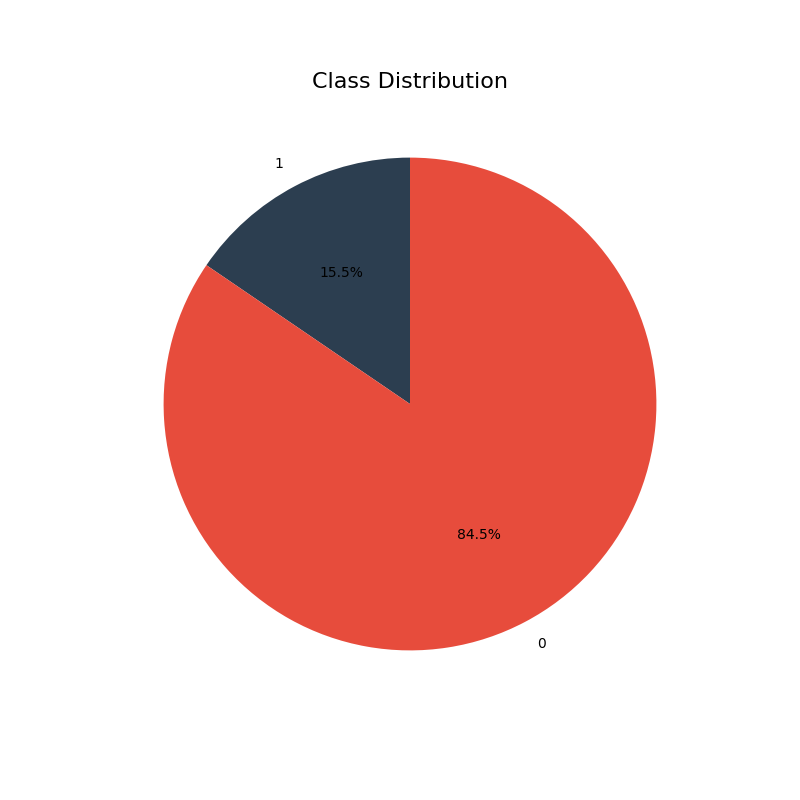

In [ ]:
%matplot plt

It is observed that the dataset is highly imbalanced. This is something expected since most entries do not result in purchase. This problem will be addressed in the following sections.

### Correlation Matrices



#### Numeric Values

I am going to use Pearson correlation coefficient to calculate the correlation between numeric features.

In [ ]:
numeric_cols = [f.name for f in dataset_df.schema.fields if f.dataType.typeName() in ['integer', 'double']]
pdf = dataset_df.select(numeric_cols).toPandas()
corr_matrix = pdf.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5,
    cbar=False,
    vmin=0,
    vmax=1
)

plt.title("Numeric Feature Correlation Matrix (Pearson)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

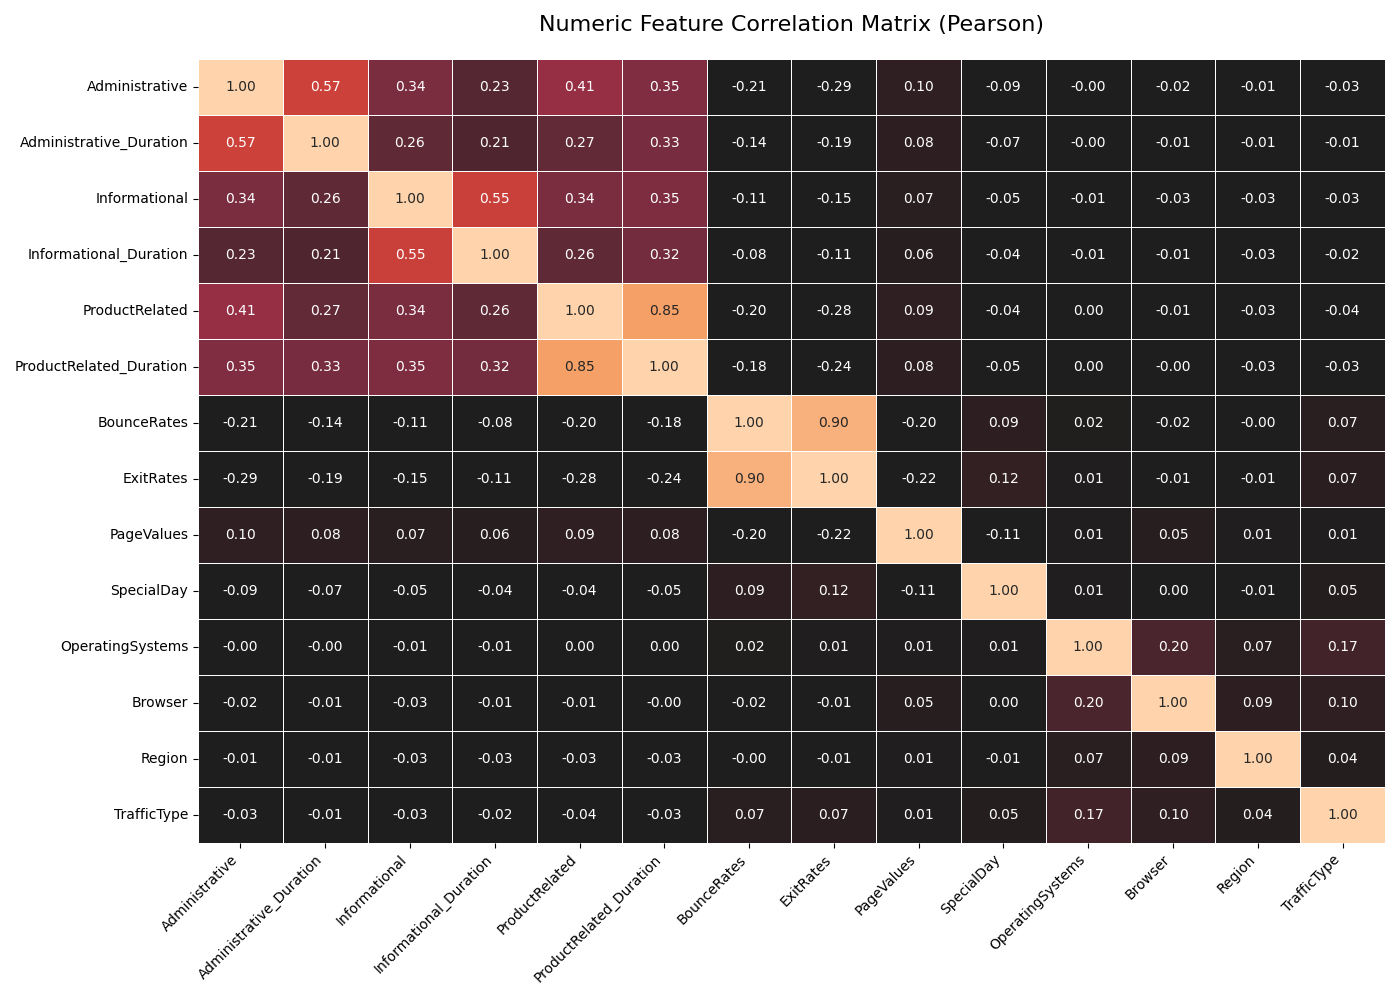

In [ ]:
%matplot plt

There is a 0.90 correlation between Bounce Rates and Exit Rates. This high correlation implies that a user who bounces is essentially a user who exits immediately.

There is also a strong 0.85 link between the number of Product Related pages visited and the Product Related Duration. This means that the more items a customer looks at, the longer they stay on the website.

It is also possible to observe that variables like Operating Systems, Browser, and Region show almost zero correlation with the behavioral metrics like page views or duration.

#### Categorical Values

I am going to use Theil's U to calculate the correlation between categorical features.

In [ ]:
cat_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Month', 'VisitorType', 'Weekend', 'Revenue']
df_cat = dataset_df.select(cat_cols).toPandas()

for col in cat_cols:
    df_cat[col] = df_cat[col].astype('category').cat.codes

matrix = torch.tensor(df_cat.values)
num_cols = matrix.shape[1]

u_tensor = torch.zeros((num_cols, num_cols))

for i in range(num_cols):
    for j in range(num_cols):
        u_tensor[i, j] = theils_u(matrix[:, i], matrix[:, j])
corr_matrix = pd.DataFrame(u_tensor.numpy(), columns=cat_cols, index=cat_cols)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    linewidth=1,
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=1
)
plt.title("Categorical Features Correlation Matrix (Theil's U)", fontsize=16)
plt.show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

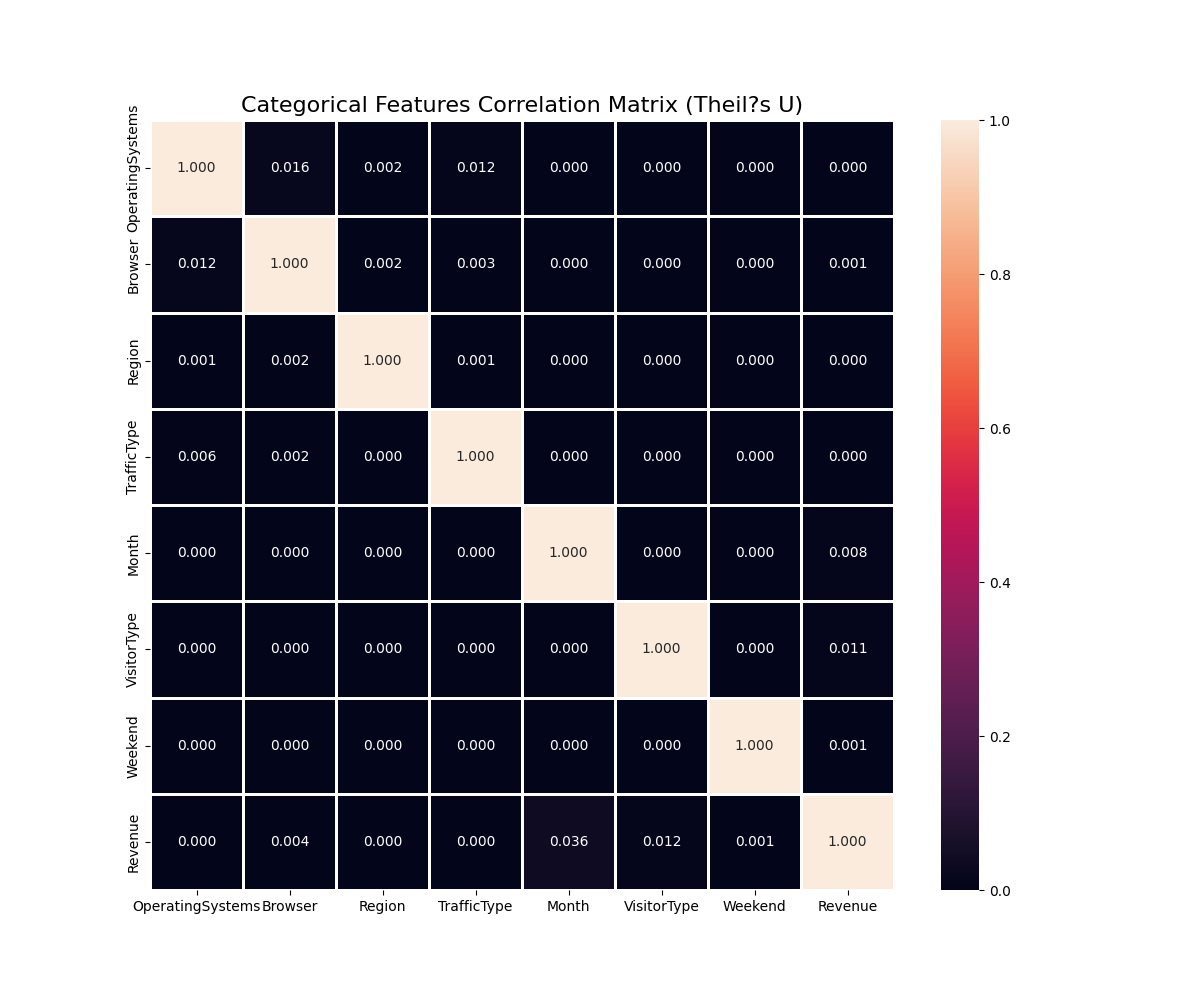

In [ ]:
%matplot plt

Variables like Browser, Operating Systems, Region, and Traffic Type have absolutely zero effect on whether a purchase is made. Knowing if a customer is using Chrome instead of Safari or what city they live in gives no clue about their likelihood to open their wallet (Revenue column).

On the other hand, the most powerful variable we have is the Month (which scored 0.036). In the e-commerce world, seasonality is everything. Months that include Black Friday, New Year's, or other holidays directly drive sales. While 0.036 might sound like a tiny number, it is actually quite valuable because it clears up 3.6% of the uncertainty all by itself.

Right behind the month is the Visitor Type, coming in as our second strongest signal with a score of 0.012. This simply shows that whether a customer is browsing the site for the first time or returning as a loyal shopper plays a noticeable role in predicting their purchasing behavior.

### Descriptive Statistics

In [ ]:
summary_for_eda = dataset_df.summary().toPandas().set_index('summary').T
display(summary_for_eda)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

summary                   count                  mean               stddev  \
Administrative           999999     2.780928780928781   2.6799125382798077   
Administrative_Duration  999999    117.85996184885876    130.0186480725116   
Informational            999999    0.7824427824427824   0.9530538919931842   
Informational_Duration   999999     74.69524397096171    94.26212053046883   
ProductRelated           999999     37.60918560918561    36.20837022508483   
ProductRelated_Duration  999999    1496.7996973450486   1507.5512839362352   
BounceRates              999999  0.031455091523439345  0.03689891015173434   
ExitRates                999999  0.047371666437569675  0.04208795710793378   
PageValues               999999      8.85457236258756   15.863276565546478   
SpecialDay               999999   0.11264953776103474  0.13843104208828594   
OperatingSystems         999999    2.1644841644841644   0.8838917067254882   
Browser                  999999    2.5625055625055624   1.440884

It is noticeable that genuine numeric features (non-categoricals) are not on the same scale. Although tree-based models do not typically require feature scaling, I will scale the numeric features to improve the baseline model (logistic regression) and to better handle extreme values. To this end, I am going to use RobustScaler, which handles extreme values efficiently by removing the median and scaling based on IQR.

### Missing Values

In [ ]:
missing_counts_df = dataset_real_df.select([
    sql_f.sum(sql_f.when(sql_f.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in dataset_real_df.columns
])

missing_summary = missing_counts_df.toPandas().T.rename(columns={0: "missing_values"})
display(missing_summary)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

                         missing_values
Administrative                        0
Administrative_Duration               0
Informational                         0
Informational_Duration                0
ProductRelated                        0
ProductRelated_Duration               0
BounceRates                           0
ExitRates                             0
PageValues                            0
SpecialDay                            0
OperatingSystems                      0
Browser                               0
Region                                0
TrafficType                           0
Month                                 0
VisitorType                           0
Weekend                               0
Revenue                               0

In [ ]:
msno.matrix(dataset_real_df.toPandas(), sparkline=False);

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

<Axes: >

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

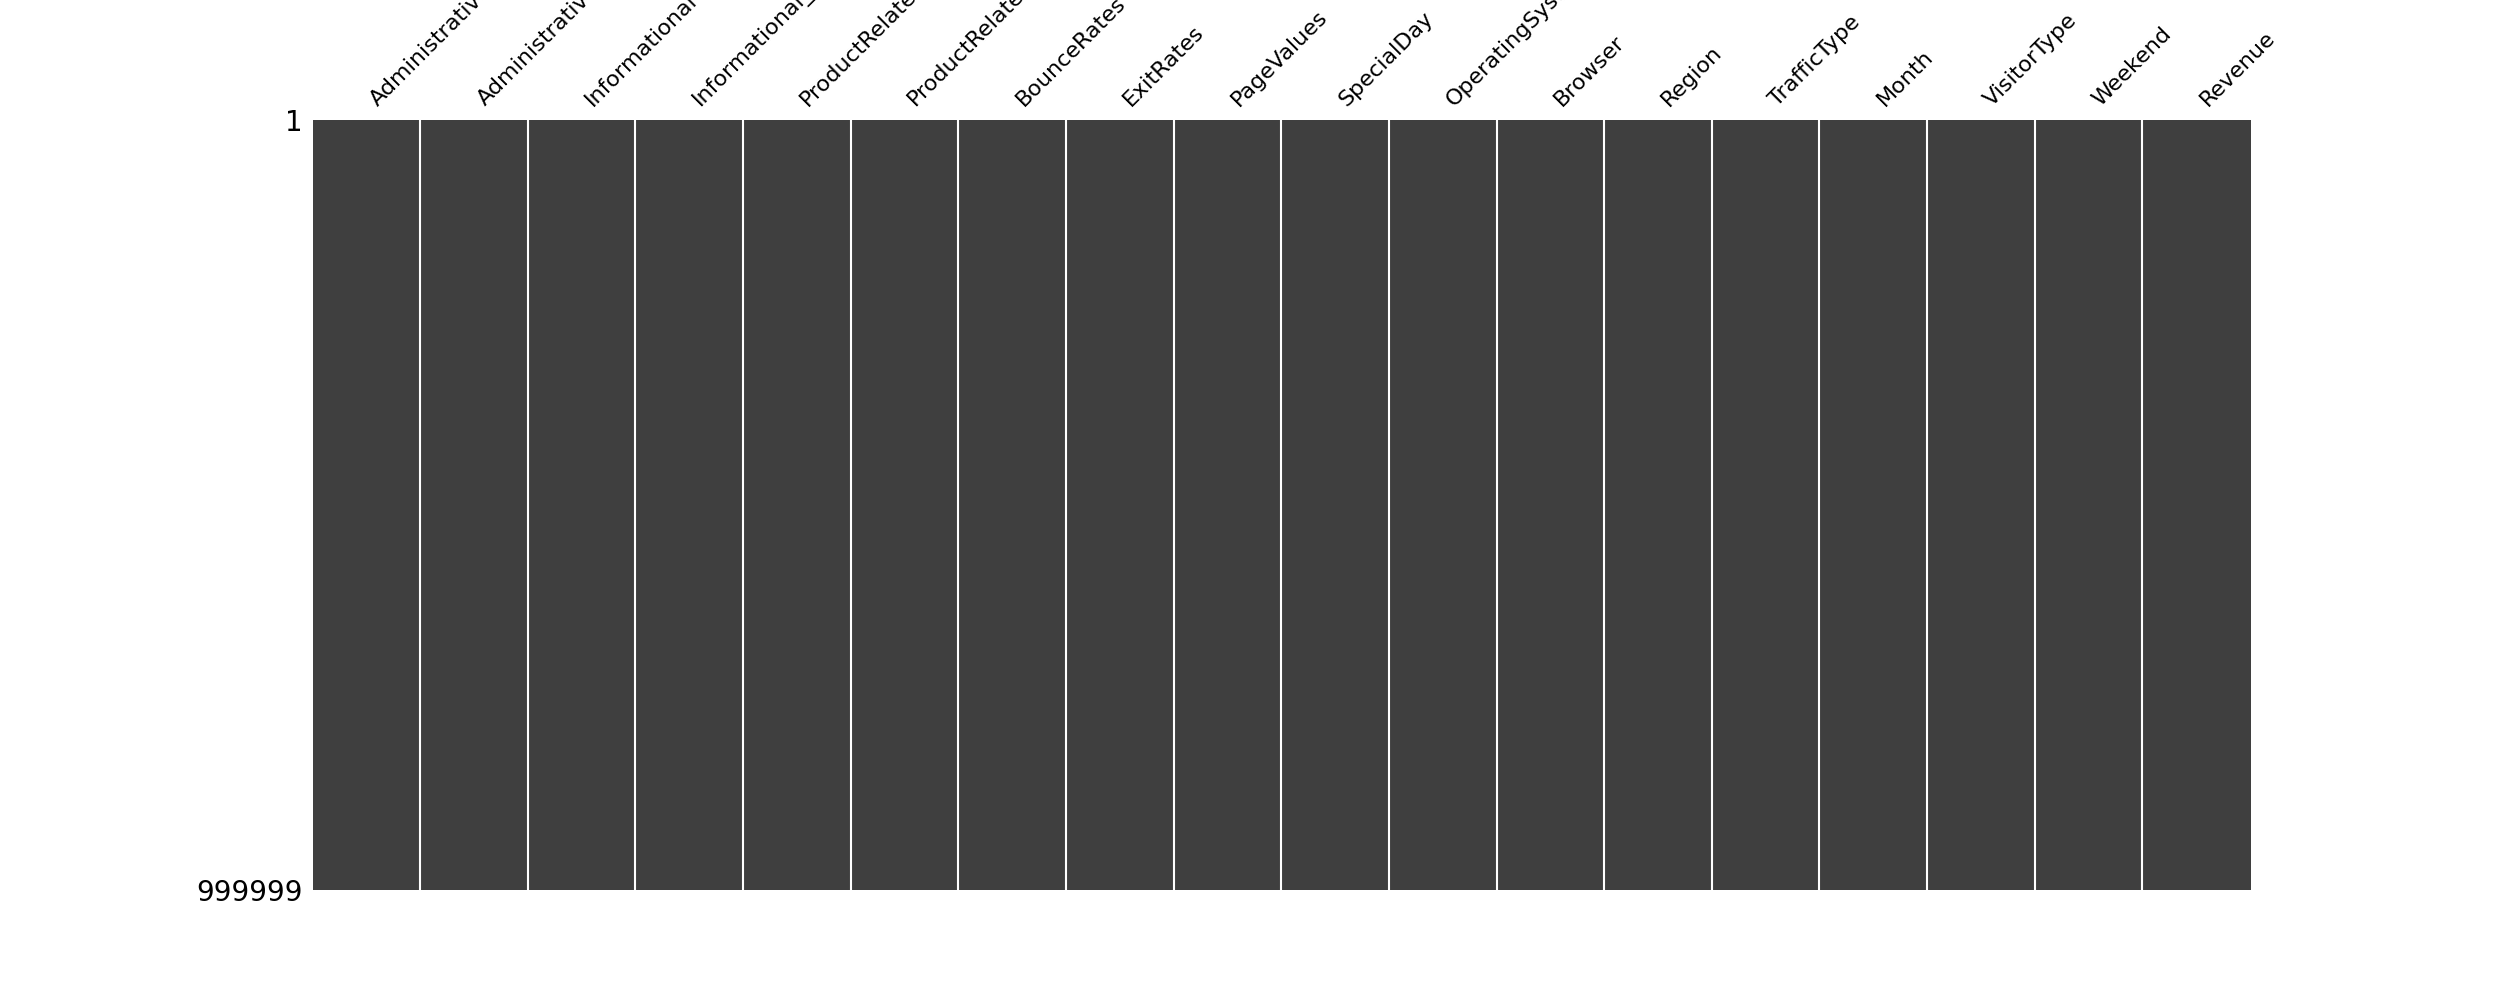

In [ ]:
%matplot plt

There are no missing values in the dataset. I do not need to implement imputation methods such as MissForest. Therefore, assumptions regarding missingness mechanisms such as MCAR or MAR are not relevant in this context.

***

## Data Selection and Preprocessing

### Feature Engineering

I will start by generating new features using mathematical interactions and proportions between the existing ones. Specifically:

* One possible interaction can be found between "ProductRelated_Duration" and "ProductRelated". By calculating "ProductRelated_Duration" / ("ProductRelated" + 1), we can simply calculate how much time the user spent on a single product page on average while also avoiding division by zero errors.

* The same logic can be applied to "Administrative_Duration" and "Administrative". Dividing the "Administrative_Duration" column by ("Administrative" + 1) will give us the average time spent on a single administrative page.

* Furthermore, "ProductRelated_Duration" / ("Administrative_Duration" + "Informational_Duration" + "ProductRelated_Duration" + 1) would give us the ratio of time the user spent inspecting products to the total time spent on the website.

* It is even possible to calculate the total page view count the user undertook by adding "Administrative" + "Informational" + "ProductRelated".

* For a more advanced approach, I also create cyclical features using the "Month" column. The calculations for this operation can be written as:

$$
\begin{aligned}
\text{Month_Sin} &= \sin\left(\frac{2\pi \cdot \text{Month}}{12}\right) \\
\text{Month_Cos} &= \cos\left(\frac{2\pi \cdot \text{Month}}{12}\right)
\end{aligned}
$$

In [ ]:
dataset_real_df = dataset_real_df.withColumn(
    "Avg_Product_Time",
    sql_f.col("ProductRelated_Duration") / (sql_f.col("ProductRelated") + sql_f.lit(1))
).withColumn(
    "Avg_Admin_Time",
    sql_f.col("Administrative_Duration") / (sql_f.col("Administrative") + sql_f.lit(1))
).withColumn(
    "Total_Duration",
    sql_f.col("Administrative_Duration") + sql_f.col("Informational_Duration") + sql_f.col("ProductRelated_Duration")
).withColumn(
    "Product_Focus_Ratio",
    sql_f.col("ProductRelated_Duration") / (sql_f.col("Total_Duration") + sql_f.lit(1))
).withColumn(
    "Total_Page_Views",
    sql_f.col("Administrative") + sql_f.col("Informational") + sql_f.col("ProductRelated")
).withColumn(
    "Month_Sin",
    sql_f.sin((sql_f.lit(2) * sql_f.lit(math.pi) * sql_f.col("Month")) / sql_f.lit(12))
).withColumn(
    "Month_Cos",
    sql_f.cos((sql_f.lit(2) * sql_f.lit(math.pi) * sql_f.col("Month")) / sql_f.lit(12))
)

dataset_real_df.limit(10).toPandas()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

   Administrative  Administrative_Duration  Informational  \
0               0                 0.000000              0   
1               3               140.433150              0   
2               2               169.063012              1   
3               4               129.698301              1   
4               2               214.526081              2   
5               0                 0.000000              0   
6               0                97.032001              1   
7               0                 0.000000              0   
8               0                 0.000000              0   
9               0                 0.000000              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                0.000000               0                 0.000000   
1              121.793138              55              2333.187358   
2               72.697027              23              1448.426947   
3              118.581521              53       

### Feature Selection

It is crucial to drop certain columns to prevent data leakage, eliminate noise, and reduce dimensionality.

* I am completely removing the "PageValues" column. Since this metric represents the average value of pages visited right before completing a transaction, including it would cause severe data leakage. It essentially feeds the model the final answer beforehand, which would result in artificially perfect scores during training but complete failure in a real scenario.

* I am also dropping "BounceRates" due to its massive 0.90 correlation with "ExitRates". Keeping both would lead to multicollinearity because they tell the exact same story about users leaving the website. I chose to retain "ExitRates" because it is a slightly broader and more useful metric for the session's end.

* I am also removing the original raw duration and page count columns, such as "ProductRelated" and "ProductRelated_Duration". Because I have already combined these numbers to engineer much stronger features such as the average time spent per page and the focus ratio.

In [ ]:
selected_features = [
  "Avg_Product_Time",
  "Avg_Admin_Time",
  "Product_Focus_Ratio",
  "Total_Duration",
  "Total_Page_Views",
  "OperatingSystems",
  "Browser",
  "Region",
  "ExitRates",
  "SpecialDay",
  "TrafficType",
  "VisitorType",
  "Weekend",
  "Month_Sin",
  "Month_Cos"
]

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

### Split

The first critical step in splitting this dataset is doing so by preserving its imbalanced nature. To ensure the algorithm learns the true distribution of the data, I am going to implement a stratified splitting strategy. I will begin by isolating a 10% test set. To support conformal prediction and generate statistically guaranteed prediction intervals I need to create a dedicated calibration set from the remaining training data. I am going to allocate a small portion (0.05) of training data for calibration. By applying the same stratified logic, I am going to divide the data into training, calibration, and testing sets.

In [ ]:
dataset_real_df.cache()

df_pos = dataset_real_df.filter(sql_f.col("Revenue") == 1)
df_neg = dataset_real_df.filter(sql_f.col("Revenue") == 0)

train_temp_pos, test_pos = df_pos.randomSplit([0.9, 0.1], seed=616)
train_temp_neg, test_neg = df_neg.randomSplit([0.9, 0.1], seed=616)

test_df = test_pos.unionByName(test_neg)

train_final_pos, calib_pos = train_temp_pos.randomSplit([0.95, 0.05], seed=616)
train_final_neg, calib_neg = train_temp_neg.randomSplit([0.95, 0.05], seed=616)

train_df = train_final_pos.unionByName(train_final_neg)
calibration_df = calib_pos.unionByName(calib_neg)

print(f"train_df size: {train_df.count()}")
print(f"test_df size: {test_df.count()}")
print(f"calibration_df size: {calibration_df.count()}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

train_df size: 855713
test_df size: 99542
calibration_df size: 44744

### Feature Scaling (Transformation)

Before moving to model training section, the features in the dataset should be transformed properly without introducing any data leakage. For categorical variables such as traffic and visitor types, I am going to avoid standard one-hot encoding. That approach would lead the feature space to blow like confetti that often confuse and slow down tree-based algorithms. Instead, I am going to implement target encoding strategy. By calculating the average purchase rate for each category strictly using only the training set, the algorithm learns to evaluate these categories based on their actual predictive potential rather than arbitrary labels. I will deliberately leave binary indicators, like the "Weekend" column, completely untouched because machine learning algorithms natively understand binary zero-and-one logic.

For the continuous numerical features, I am going to apply a robust scaler. While it is true that tree-based algorithms do not benefit from such transformations, I am also planning to create an additional basic model like logistic regression (which benefits from standardization a lot) in order to compare the results with tree-based algorithms. Furthermore, RobustScaler excels at neutralizing extreme outliers. So as to guarantee mathematical isolation, the scaling operations and the target encoding maps will be learned exclusively from the training data and merely applied to the calibration and test sets.

***

## Hyperparameter Tuning and Model Training

I am going to use some of the frontier algorithms used widely in industry, which are LightGBM, XGBoost, and additionally, Random Forest. I will also designate a Logistic Regression model as my baseline model. Because it is very fast and cheap to train, it perfectly answers the core business question: "Does the complexity and computational cost of advanced tree-based models actually yield a significant advantage over a basic mathematical approach?"

I am going to use Optuna package for hyperparameter tuning. Instead of relying on blind Grid Search or Random Search, I am going to use the TPE (Tree-structured Parzen Estimator) sampler. TPE is a Bayesian optimization algorithm that learns from the results of previous trials to intelligently guess the next best set of parameters. In terms of parameters, I will set a value of 200 for `n_trials` because higher values give marginal returns. I will randomize the first 20 trials by setting `n_startup_trials` to 20 in order to gather diverse baseline data before the Bayesian probability engine kicks in. However, I am going to use a much smaller experimentation set for Random Forest because it is computationally much more demanding than the other algorithms to train.

I will use Optuna's Successive Halving Pruner to kill the trial if a specific hyperparameter set performs poorly in the first few folds. For the boosting models that learn iteratively (LightGBM and XGBoost/CatBoost), I am going to embed an early stopping mechanism. If a model fails to improve its log loss over a consecutive number of trees (epochs), it halts the training for that specific fold. AWS EMR will be used to leverage CPU resources.

### The Optimization Metric: Why the Brier Score?
Perhaps the most critical architectural decision in this pipeline is the choice of the optimization metric. While many classification tasks default to ROC-AUC or Log Loss, I am going to minimize the Brier Score for this project. The reasoning is deeply tied to business utility. AUC purely measures ranking (does the model score a buyer higher than a non-buyer?), but it completely ignores the actual truth of the probabilities.

Brier Score, essentially the mean squared error of probabilities, forces the models to be perfectly calibrated. In a real-world business scenario, if our model predicts an 80% probability of a customer making a purchase, we need that customer to actually purchase exactly 8 out of 10 times. By aggressively optimizing the Brier Score, I ensure that our models do not just separate classes, but output reliable probabilities.

### Architectural Shift and Leakage Prevention
In this step, I will shift from PySpark to the native Python ecosystem (particularly pandas and sklearn). The reason is that:

PySpark is undeniably the gold standard for distributed data engineering and it flawlessly handled the initial raw data extraction and stratified splitting without hitting any memory bottlenecks. However, utilizing Spark MLlib for the entire hyperparameter tuning phase would have created a massive performance bottleneck due to JVM communication overhead across thousands of trials.

To prevent data leakage during the 3-fold cross-validation, I intentionally moved the preprocessing steps out of Spark and integrated them directly into Scikit-Learn Pipeline objects. This ensures that scaling and encoding statistics are calculated strictly on the training folds.

The reason for using 3 folds in cross-validation is that I am dealing with a relatively large dataset. Using more folds would not provide significant benefits due to the law of large numbers but would significantly increase training time.

In [ ]:
columns_to_fetch = selected_features + ["Revenue"]

train_pd = train_df.select(*columns_to_fetch).toPandas()
calib_pd = calibration_df.select(*columns_to_fetch).toPandas()
test_pd = test_df.select(*columns_to_fetch).toPandas()

X_train = train_pd[selected_features]
y_train = train_pd["Revenue"].values

X_calib = calib_pd[selected_features]
y_calib = calib_pd["Revenue"].values

X_test = test_pd[selected_features]
y_test = test_pd["Revenue"].values

categorical_cols = ["TrafficType", "VisitorType", "OperatingSystems", "Browser", "Region"]
numeric_cols = ["Avg_Product_Time", "Avg_Admin_Time", "Total_Duration", "Total_Page_Views", "ExitRates", "Product_Focus_Ratio"]

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
class SilentLogger:
    def info(self, msg):
        pass
    def warning(self, msg):
        pass

register_logger(SilentLogger())

optuna.logging.disable_default_handler()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
def objective_lr(trial):
    C = trial.suggest_float("C", 1e-4, 10.0, log=True)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=616)
    brier_scores = []

    preprocessor = ColumnTransformer(
        transformers=[
            ('target_enc', TargetEncoder(random_state=616), categorical_cols),
            ('scaler', RobustScaler(), numeric_cols)
        ],
        remainder='passthrough'
    )

    for step, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(
                C=C,
                max_iter=1000,
                random_state=616,
                n_jobs=1
            ))
        ])

        model_pipeline.fit(X_tr, y_tr)

        preds = model_pipeline.predict_proba(X_val)[:, 1]

        fold_score = brier_score_loss(y_val, preds)
        brier_scores.append(fold_score)

        current_mean_score = np.mean(brier_scores)
        trial.report(current_mean_score, step)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(brier_scores)

pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3)

study_lr = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(n_startup_trials=20, n_ei_candidates=24, seed=616),
    pruner=pruner
)

study_lr.optimize(objective_lr, n_trials=200, n_jobs=-1)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
def objective_lgb(trial):
    param = {
        "objective": "binary",
        "n_estimators": trial.suggest_int("n_estimators", 500, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.01, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "verbosity": -1,
        "verbose": -1,
        "force_row_wise": True,
        "random_state": 616,
        "n_jobs": 1
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=616)
    brier_scores = []

    for step, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        preprocessor = ColumnTransformer(
            transformers=[
                ('target_enc', TargetEncoder(random_state=616), categorical_cols),
                ('scaler', RobustScaler(), numeric_cols)
            ],
            remainder='passthrough'
        )

        X_tr_transformed = preprocessor.fit_transform(X_tr, y_tr)
        X_val_transformed = preprocessor.transform(X_val)

        model = LGBMClassifier(**param)

        model.fit(
            X_tr_transformed, y_tr,
            eval_set=[(X_val_transformed, y_val)],
            eval_metric="binary_logloss",
            callbacks=[
                early_stopping(stopping_rounds=50, verbose=False)
            ]
        )

        preds = model.predict_proba(X_val_transformed)[:, 1]
        fold_score = brier_score_loss(y_val, preds)
        brier_scores.append(fold_score)

        current_mean_score = np.mean(brier_scores)
        trial.report(current_mean_score, step)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(brier_scores)

pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3)

study_lgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(n_startup_trials=20, n_ei_candidates=24, seed=616),
    pruner=pruner
)

study_lgb.optimize(objective_lgb, n_trials=200, n_jobs=-1)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
def objective_xgb(trial):
    param = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_estimators": trial.suggest_int("n_estimators", 500, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.01, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "verbosity": 0,
        "random_state": 616,
        "n_jobs": 1,
        "early_stopping_rounds": 50
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=616)
    brier_scores = []

    for step, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        preprocessor = ColumnTransformer(
            transformers=[
                ('target_enc', TargetEncoder(random_state=616), categorical_cols),
                ('scaler', RobustScaler(), numeric_cols)
            ],
            remainder='passthrough'
        )

        X_tr_transformed = preprocessor.fit_transform(X_tr, y_tr)
        X_val_transformed = preprocessor.transform(X_val)

        model = xgb.XGBClassifier(**param)

        model.fit(
            X_tr_transformed, y_tr,
            eval_set=[(X_val_transformed, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val_transformed)[:, 1]
        fold_score = brier_score_loss(y_val, preds)
        brier_scores.append(fold_score)

        current_mean_score = np.mean(brier_scores)
        trial.report(current_mean_score, step)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(brier_scores)

pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3)

study_xgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(n_startup_trials=20, n_ei_candidates=24, seed=616),
    pruner=pruner
)

study_xgb.optimize(objective_xgb, n_trials=200, n_jobs=-1)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
def objective_rf(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "max_samples": trial.suggest_float("max_samples", 0.2, 0.8),
        "random_state": 616,
        "n_jobs": 1,
        "verbose": 0
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=616)
    brier_scores = []

    preprocessor = ColumnTransformer(
        transformers=[
            ('target_enc', TargetEncoder(random_state=616), categorical_cols),
            ('scaler', RobustScaler(), numeric_cols)
        ],
        remainder='passthrough'
    )

    for step, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(**param))
        ])

        model_pipeline.fit(X_tr, y_tr)
        preds = model_pipeline.predict_proba(X_val)[:, 1]

        fold_score = brier_score_loss(y_val, preds)
        brier_scores.append(fold_score)

        current_mean_score = np.mean(brier_scores)
        trial.report(current_mean_score, step)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(brier_scores)

pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3)

study_rf = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(n_startup_trials=8, n_ei_candidates=24, seed=616),
    pruner=pruner
)

study_rf.optimize(objective_rf, n_trials=80, n_jobs=-1)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

### Creating an Ensemble

My foundational models (LightGBM, XGBoost, and Random Forest) already utilize sequential boosting and parallel bagging. Attempting to apply yet another layer of bagging or boosting on top of these models would introduce massive computational latency with almost no gain in predictive power. Stacking, however, operates in a different way where it leverages the algorithmic diversity of heterogenous models. The Stacked Ensemble acts as a board of directors by taking the distinct approach of each algorithm to form a consensus rather than forcing them to go through the same operations again.

But why logistic regression as a meta-learner? Complex meta-learners tend to aggressively memorize predictions provided by the base estimators, which leads to overfitting. Thus, it strictly evaluates which base model is most trustworthy in specific probability ranges without overcomplicating the final decision boundary. By passing tree-based learners' raw predictions through a linear meta-learner, it is expected to see the Stacked Ensemble smooth out these overconfident spikes. I anticipate this architecture to yield the lowest Brier Score.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(random_state=616), categorical_cols),
        ('scaler', RobustScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

lgb_params = {
    "objective": "binary",
    "verbosity": -1, "verbose": -1, "force_row_wise": True,
    **study_lgb.best_params,
    "random_state": 616, "n_jobs": 1
}

xgb_params = {
    "objective": "binary:logistic", "eval_metric": "logloss",
    "verbosity": 0,
    **study_xgb.best_params,
    "random_state": 616, "n_jobs": 1
}

rf_params = {
    "verbose": 0,
    **study_rf.best_params,
    "random_state": 616, "n_jobs": 1
}

lr_params = {
    "max_iter": 1000,
    **study_lr.best_params,
    "random_state": 616, "n_jobs": 1
}

lgb_pipeline = Pipeline([('preprocessor', preprocessor), ('clf', LGBMClassifier(**lgb_params))])
xgb_pipeline = Pipeline([('preprocessor', preprocessor), ('clf', xgb.XGBClassifier(**xgb_params))])
rf_pipeline = Pipeline([('preprocessor', preprocessor), ('clf', RandomForestClassifier(**rf_params))])
meta_learner = LogisticRegression(**lr_params)

base_estimators = [
    ('lightgbm', lgb_pipeline),
    ('xgboost', xgb_pipeline),
    ('random_forest', rf_pipeline)
]

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=3,
    n_jobs=-1,
    passthrough=False
)
stacking_clf.fit(X_train, y_train)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

StackingClassifier(cv=3,
                   estimators=[('lightgbm',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('target_enc',
                                                                                  TargetEncoder(random_state=616),
                                                                                  ['TrafficType',
                                                                                   'VisitorType',
                                                                                   'OperatingSystems',
                                                                                   'Browser',
                                                                                   'Region']),
                                                                           

In [ ]:
baseline_lr = Pipeline([('preprocessor', preprocessor), ('clf', LogisticRegression(**lr_params))])
baseline_lr.fit(X_train, y_train)

models = {
  "Logistic Regression (Baseline)": baseline_lr,
  "LightGBM": stacking_clf.named_estimators_['lightgbm'],
  "XGBoost": stacking_clf.named_estimators_['xgboost'],
  "Random Forest": stacking_clf.named_estimators_['random_forest'],
  "Stacked Ensemble": stacking_clf
}

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

### Feature Importance

In [ ]:
rf_pipeline = stacking_clf.named_estimators_['random_forest']
fitted_preprocessor = rf_pipeline.named_steps['preprocessor']
actual_rf_model = rf_pipeline.named_steps['clf']

X_test_transformed = fitted_preprocessor.transform(X_test)
raw_feature_names = fitted_preprocessor.get_feature_names_out()
X_test_sampled = shap.sample(X_test_transformed, 200, random_state=616)

explainer = shap.TreeExplainer(actual_rf_model)
shap_values = explainer.shap_values(X_test_sampled, check_additivity=False)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

plt.figure(figsize=(12, 8))
plt.title("Random Forest - SHAP Feature Impact (Revenue = 1)", fontsize=14, fontweight='bold')

shap.summary_plot(shap_values_pos, X_test_sampled, feature_names=raw_feature_names, show=False)
plt.tight_layout()
plt.show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

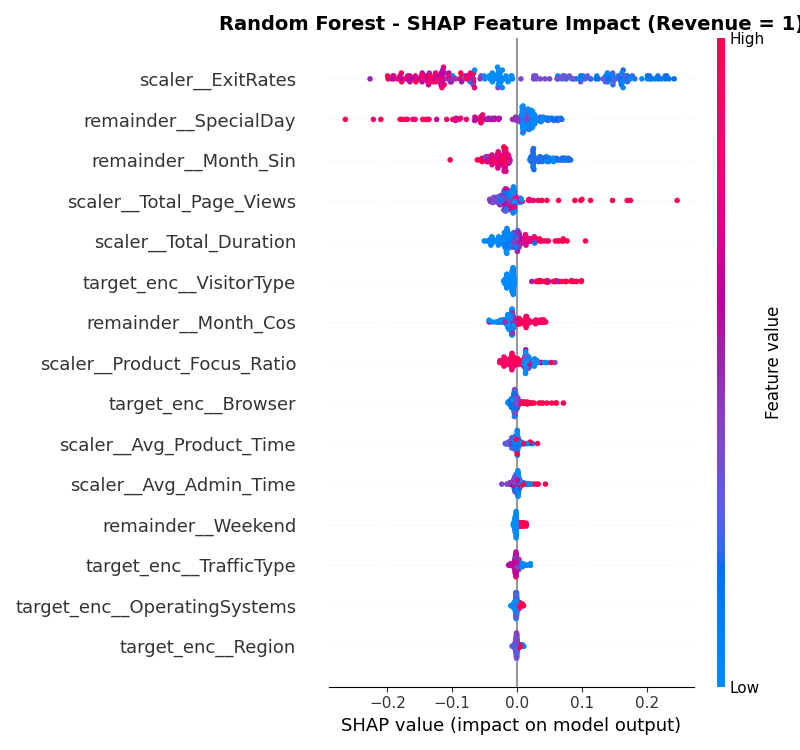

In [ ]:
%matplot plt

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Random Forest - Mean Absolute SHAP Values (Feature Importance)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values_pos, X_test_sampled, feature_names=raw_feature_names, plot_type="bar", show=False, color="royalblue")
plt.tight_layout()
plt.show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

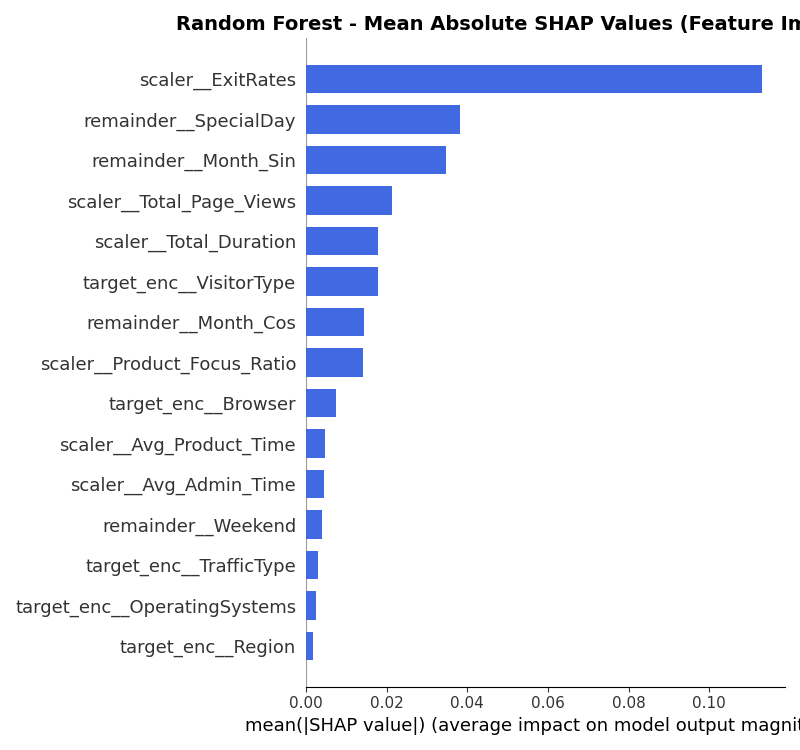

In [ ]:
%matplot plt

The bar plot tells how important a feature is in general. The beeswarm plot shows the direction and magnitude of that feature's influence on each individual customer.

It is clear that ExitRates is the most important feature the model uses as the bar plot indicates. There is a tight cluster of blue dots (low ExitRates) far to the right, which signifies a very high positive impact on purchase probability. On the other hand, pink/red dots (high ExitRates) are heavily clustered on the left (negative SHAP values). These results simply indicate that customers who visit pages that are frequently the final page in a session are much less likely to buy. Minimal ExitRates are the strongest indicator of intent.

SpecialDay emerges as the second strongest feature with its low values showing a positive impact on purchase probability. Month_Sin occupies the third position. It shows a strong negative relationship in the beeswarm plot: high Month_Sin values (often associated with late spring or summer months in a sinusoidal transform) decrease the likelihood of purchase (large blue cluster on the right, pink on the left). Low Month_Sin values, which typically correspond to the winter/holiday shopping season, have a positive impact. Seasonal cyclicality is a major driver of behavior.

Total_Page_Views and Total_Duration occupy positions fourth and fifth. In both beeswarm plots, pink/red dots (high values) spread far to the right, which means that they show a clear positive correlation with purchase probability. The blue clusters on the other hand are dense around zero or slightly negative. Viewing more pages and staying longer can be used as a reliable predictor of intent.

For VisitorType_TE, it is seen a distinct pink cluster centered on the positive SHAP axis. High values here (associated with the "Returning Visitor" category from the target encoding) have a predictable positive impact on likelihood whereas low values ("New Visitor") do not.

Product_Focus_Ratio shows a negative relationship. Blue dots (low ratio values) are on the right, while pink dots (high values) are on the left. A low "Product Focus Ratio" in engineered feature means a higher percentage of time spent on product-related pages versus other types. This means that customers focused primarily on products have higher intent.

And for the variable Weekend, it is seen a distinct pink cluster on the positive side of zero. The probability of a customer purchasing increases on the weekend.

Both plots confirm that features like Avg_Product_Time and Avg_Admin_Time have very little impact on the model's final output. The dots are all tightly clustered around the zero line and they rank near the bottom of the importance chart. Spending time on an individual product page or administrative page does not matter nearly as much as the total engagement and aggregate views.

***

## Calibration and Threshold-tuning

In a real world e-commerce environment, taking action based on raw model outputs without quantifying uncertainty is a massive risk. I am therefore going to use a conformalization framework to overcome this issue. Thus, I will ensure a guaranteed confidence interval for probability outcomes for any given error tolerance (such as 90% or 95% confidence). If the model is highly certain, it outputs a single class [1] but if the customer's behavior is borderline, it outputs a set of both classes [0, 1], which means the prediction is uncertain. This acts as the ultimate risk management shield. It is thus possible to allow stakeholders to easily identify which predictions are solid and which require a cautious approach.

In [ ]:
class Calibrator(BaseEstimator, ClassifierMixin, MetaEstimatorMixin):
    def __init__(self, estimator=None, optimal_threshold=0.50):
        self.estimator = estimator
        self.optimal_threshold = optimal_threshold

    def fit(self, X_cal, y_cal):
        proba_cal = self.estimator.predict_proba(X_cal)
        scores = 1.0 - proba_cal[np.arange(len(y_cal)), y_cal.astype(int)]
        self.calib_scores_ = np.sort(scores)
        self.classes_ = np.array([0, 1])
        return self

    def predict_sets(self, X, alpha=0.10):
        check_is_fitted(self, 'calib_scores_')
        n = len(self.calib_scores_)
        k = math.ceil((n + 1) * (1 - alpha))
        k = min(k, n)
        qhat = self.calib_scores_[k - 1]
        tau = 1.0 - qhat
        proba = self.estimator.predict_proba(X)
        return [np.where(p >= tau)[0] for p in proba]

    def predict_proba(self, X):
        check_is_fitted(self, 'calib_scores_')
        return self.estimator.predict_proba(X)

    def predict(self, X):
        check_is_fitted(self, 'calib_scores_')
        proba = self.estimator.predict_proba(X)[:, 1]
        return (proba >= self.optimal_threshold).astype(int)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

While the calibration step is very useful for risk analysis, some business operations (like automated email campaigns or targeted ads) require binary triggers. An automated system cannot execute a marketing campaign based on a [0, 1] output. It needs a definitive 1 or 0. Therefore I still need to find an optimal specific probability threshold triggers a "Purchase Predicted" flag. I am going to optimize specifically for the F2 Score.

### Why the F2-Score?
Traditional metrics like Log Loss or the Brier Score evaluate the smoothness of the probability curve but not the profitability of the final "yes" or "no" decision the marketing team intends to get. To maximize revenue, it is necessary to prioritize capturing every potential buyer (high recall) while maintaining a reasonable level of accuracy (precision). If the model is overly optimistic and the marketing team accidentally sends an email coupon to a user who was never going to buy (false positive), the cost is zero. But if the marketing team fails to send a coupon to a high-intent customer who just needed a slight nudge (false negative), an entire sale is lost. The model must prioritize capturing as many potential buyers as possible (high recall) without completely losing its exactness (precision) to maximize company revenue. F2 Score is important at this point in that the standard F1 Score treats precision and recall equally but the F2 Score weights recall twice as heavily.

Then why did not I optimize the F2-Score instead of the Brier Score during hyperparameter tuning? To the F2-Score a customer with a 51% probability of buying looks exactly the same as a customer with a 99% probability. If the algorithm is forced to train based on this metric, the model stops learning about customer behavior. It just focuses on crossing an arbitrary finish line instead. The Brier Score on the other hand is a continuous probabilistic metric and it penalizes overconfidence. I force the model to be honest and accurately reflect the true probability of the real world by optimizing the Brier Score first.

It is possible to tune the threshold using out-of-fold predictions via cross validation. I use these out-of-fold predictions to compare model performance in what follows.

In [ ]:
optimal_thresholds = {}
oof_f2_scores = {}

thresholds = np.linspace(0.01, 0.99, 100)

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()
fig.delaxes(axes[-1])

plt.style.use('seaborn-v0_8-whitegrid')
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=616)

for idx, (model_name, model) in enumerate(models.items()):

    oof_preds = cross_val_predict(model, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1)
    y_prob_oof = oof_preds[:, 1]

    f2_scores = []
    precisions = []
    recalls = []

    best_t = 0.50
    best_f2 = -1

    for t in thresholds:
        y_pred = (y_prob_oof >= t).astype(int)

        f2 = fbeta_score(y_train, y_pred, beta=2, zero_division=0)
        precision = precision_score(y_train, y_pred, zero_division=0)
        recall = recall_score(y_train, y_pred, zero_division=0)

        f2_scores.append(f2)
        precisions.append(precision)
        recalls.append(recall)

        if f2 > best_f2:
            best_f2 = f2
            best_t = t

    optimal_thresholds[model_name] = best_t
    oof_f2_scores[model_name] = best_f2

    ax = axes[idx]
    ax.plot(thresholds, f2_scores, label='F2 Score (Target)', color='green', linewidth=3)
    ax.plot(thresholds, precisions, label='Precision', color='blue', linestyle='--')
    ax.plot(thresholds, recalls, label='Recall', color='red', linestyle='-.')

    ax.axvline(best_t, color='black', linestyle=':', linewidth=2, label=f'Optimal T: {best_t:.2f}')

    ax.set_title(f"{model_name} - Threshold Tuning", fontsize=13, fontweight='bold')
    ax.set_xlabel("Probability Threshold", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Out-of-Fold (OOF) F2 Scores")
for model, score in oof_f2_scores.items():
    print(f"{model}: {score:.4f}")
best_model_name = max(oof_f2_scores, key=oof_f2_scores.get)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Out-of-Fold (OOF) F2 Scores
Logistic Regression (Baseline): 0.6220
LightGBM: 0.6936
XGBoost: 0.6933
Random Forest: 0.6895
Stacked Ensemble: 0.6934

LightGBM achieves the highest F2 Score with a value of 0.6936. It is followed by Stacked Ensemble and XGBoost with marginal differences (0.6934 and 0.6933 respectively). I believe that the reason why the stacked ensemble could not achieve the highest score is that there is not much diversity among its base learners. Since XGBoost, LightGBM, and Random Forest are all tree-based models, they lack diversity. Better performance may be achieved by combining algorithms that use different prediction methods. The worst-performing algorithm is logistic regression with an F2 score of 0.6220, which represents a considerable difference compared to the other algorithms. This is expected as it is the simplest model among them and took only about 15 minutes of tuning.

Roughly speaking, all algorithms achieved their highest F2 scores at decision thresholds between 0.10-0.18.

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

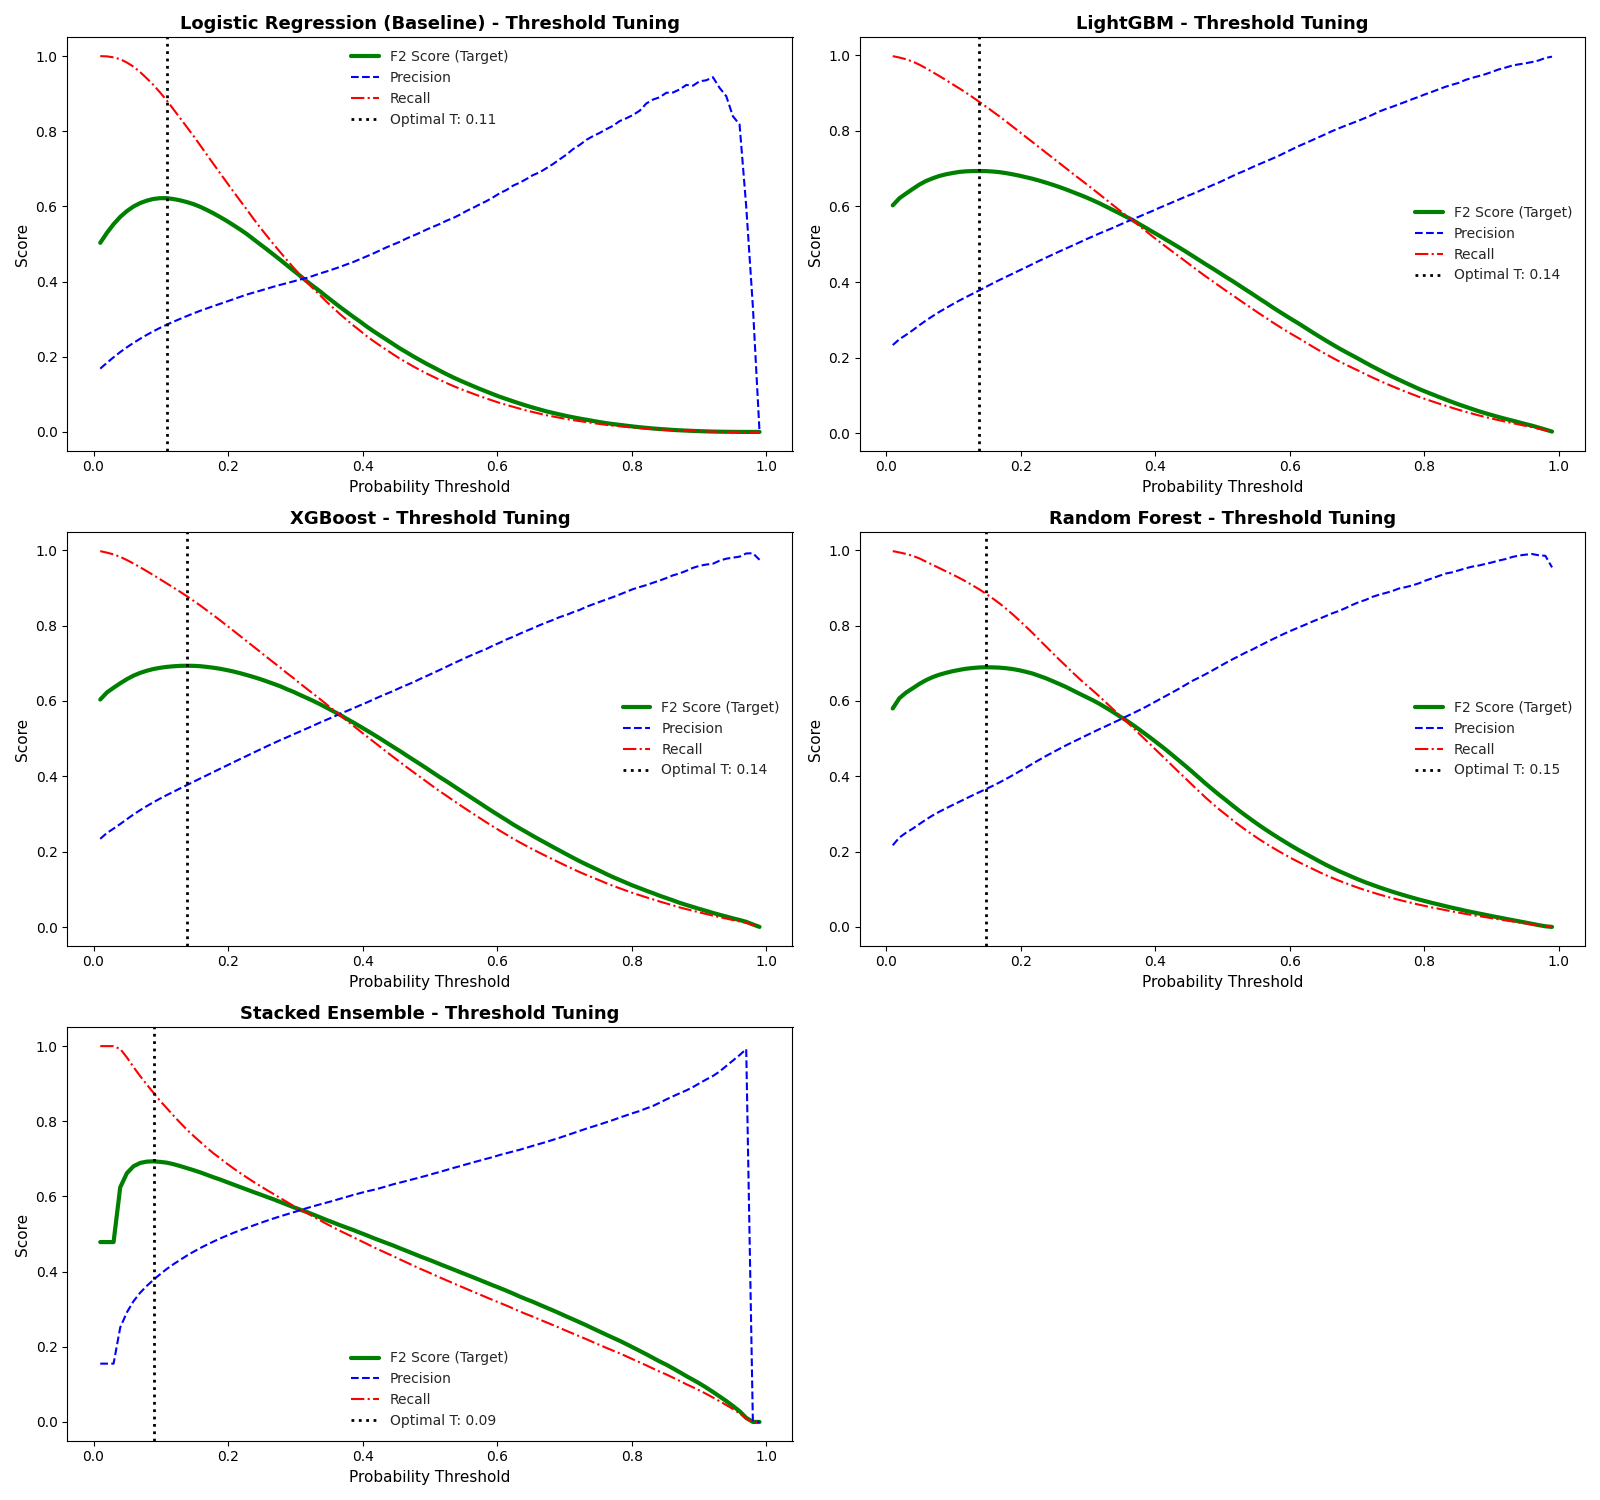

In [ ]:
%matplot plt

After threshold-tuning, I apply my calibration logic on each of the algorithms:

In [ ]:
calibrated_pipelines = {}
for model_name, model in models.items():
    best_t = optimal_thresholds[model_name]
    icp_pipeline = Calibrator(estimator=model, optimal_threshold=best_t)
    icp_pipeline.fit(X_calib, y_calib)
    calibrated_pipelines[model_name] = icp_pipeline

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Calibrator(estimator=Pipeline(steps=[('preprocessor',
                                      ColumnTransformer(remainder='passthrough',
                                                        transformers=[('target_enc',
                                                                       TargetEncoder(random_state=616),
                                                                       ['TrafficType',
                                                                        'VisitorType',
                                                                        'OperatingSystems',
                                                                        'Browser',
                                                                        'Region']),
                                                                      ('scaler',
                                                                       RobustScaler(),
                                                                       ['Av

***

## End-to-end ML Pipeline

What if I want to squish every operation I did so far into a single pipeline? Think of this pipeline as a highly automated assembly line. At the one end, we feed it completely raw customer data straight from the database. Once the data enters the pipeline, it flows through the entire system without any human intervention. The pipeline automatically cleans the data, executes feature engineering by removing irrelevant columns and creating new features using the interaction logic discussed earlier, applies the optimal decision threshold, makes predictions using the tuned model, and outputs a decision table for the marketing team. I specifically create a single end-to-end ML pipeline using the best-performing model (LightGBM).

In [ ]:
def apply_spark_feature_engineering(df):
    return df.withColumn(
        "Avg_Product_Time",
        sql_f.col("ProductRelated_Duration") / (sql_f.col("ProductRelated") + sql_f.lit(1))
    ).withColumn(
        "Avg_Admin_Time",
        sql_f.col("Administrative_Duration") / (sql_f.col("Administrative") + sql_f.lit(1))
    ).withColumn(
        "Total_Duration",
        sql_f.col("Administrative_Duration") + sql_f.col("Informational_Duration") + sql_f.col("ProductRelated_Duration")
    ).withColumn(
        "Product_Focus_Ratio",
        sql_f.col("ProductRelated_Duration") / (sql_f.col("Total_Duration") + sql_f.lit(1))
    ).withColumn(
        "Total_Page_Views",
        sql_f.col("Administrative") + sql_f.col("Informational") + sql_f.col("ProductRelated")
    ).withColumn(
        "Month_Sin",
        sql_f.sin((sql_f.lit(2) * sql_f.lit(math.pi) * sql_f.col("Month")) / sql_f.lit(12))
    ).withColumn(
        "Month_Cos",
        sql_f.cos((sql_f.lit(2) * sql_f.lit(math.pi) * sql_f.col("Month")) / sql_f.lit(12))
    )

inference_schema = StructType([
    StructField("Raw_Probability", FloatType(), True),
    StructField("Tuned_Prediction", IntegerType(), True),
    StructField("CP_Set_99", ArrayType(IntegerType()), True),
    StructField("CP_Set_95", ArrayType(IntegerType()), True),
    StructField("CP_Set_90", ArrayType(IntegerType()), True),
    StructField("CP_Set_80", ArrayType(IntegerType()), True)
])

@pandas_udf(inference_schema)
def predict_and_calibrate_udf(features_df: pd.DataFrame) -> pd.DataFrame:
    state = champion_broadcast.value
    base_estimator = state["estimator"]
    calib_scores = state["calib_scores"]
    opt_threshold = state["optimal_threshold"]
    X_pandas = features_df
    all_proba = base_estimator.predict_proba(X_pandas)
    probs = all_proba[:, 1]
    preds = (probs >= opt_threshold).astype(int)

    def get_cp_sets(alpha_val):
        n = len(calib_scores)
        k = math.ceil((n + 1) * (1 - alpha_val))
        k = min(k, n)
        qhat = calib_scores[k - 1]
        tau = 1.0 - qhat
        return [np.where(p >= tau)[0].tolist() for p in all_proba]

    return pd.DataFrame({
        "Raw_Probability": probs,
        "Tuned_Prediction": preds,
        "CP_Set_99": get_cp_sets(0.01),
        "CP_Set_95": get_cp_sets(0.05),
        "CP_Set_90": get_cp_sets(0.10),
        "CP_Set_80": get_cp_sets(0.20)
    })

def execute_full_pipeline(raw_spark_df, model_udf, feature_cols):
    engineered_df = apply_spark_feature_engineering(raw_spark_df)
    struct_col = sql_f.struct(*[sql_f.col(c) for c in feature_cols])
    result_df = engineered_df.withColumn("predictions_struct", model_udf(struct_col))

    original_cols = [sql_f.col(c) for c in raw_spark_df.columns]

    final_decision_df = result_df.select(
        *original_cols,
        sql_f.col("predictions_struct.Raw_Probability").alias("Raw_Probability"),
        sql_f.col("predictions_struct.Tuned_Prediction").alias("Tuned_Prediction"),
        sql_f.col("predictions_struct.CP_Set_99").alias("CP_99_Set"),
        sql_f.col("predictions_struct.CP_Set_95").alias("CP_95_Set"),
        sql_f.col("predictions_struct.CP_Set_90").alias("CP_90_Set"),
        sql_f.col("predictions_struct.CP_Set_80").alias("CP_80_Set")
    )

    return final_decision_df

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Now it is time to log the pipeline's details using MLflow

In [ ]:
def evaluate_model_pipeline(y_true, y_prob, y_pred):
    return {
        "Log_Loss": log_loss(y_true, y_prob),
        "Brier_Score": brier_score_loss(y_true, y_prob),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F2_Score": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0)
    }

run_name = best_model_name.replace(" ", "_")

with mlflow.start_run(run_name=run_name):

    bt = round(best_model.optimal_threshold, 3)
    mlflow.log_param("Decision_Threshold", bt)
    mlflow.log_param("Model_Architecture", best_model_name)

    if isinstance(X_train, pd.DataFrame):
        X_sample_for_signature = X_train.copy()
        integer_cols = X_sample_for_signature.select_dtypes(include=['integer', 'int64', 'int32']).columns
        X_sample_for_signature[integer_cols] = X_sample_for_signature[integer_cols].astype('float64')
    else:
        X_sample_for_signature = X_train

    pred_sample = best_model.predict(X_train)
    signature = infer_signature(X_sample_for_signature, pred_sample)
    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path=f"{run_name}_artifact",
        signature=signature
    )

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

0.139
'LightGBM'
🏃 View run LightGBM at: http://18.175.221.63:5000/#/experiments/1/runs/8f2f8d8e8e7b4d82a77102b21eb53ed1
🧪 View experiment at: http://18.175.221.63:5000/#/experiments/1
2026/04/03 13:54:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 13:54:19 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp2f9xkhdn/model/model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.6.1', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.

***

## Interpreting Predictions Using the Best Model



I previously used out-of-fold F2 scores to compare the models and select the best one. But how does the best-performing model perform on the test set? I retrieve my end-to-end pipeline from the MLflow registry to make predictions on the test set.

In [ ]:
latest_run = runs_df.sort_values(by="start_time", ascending=False).iloc[0]

champion_run_id = latest_run["run_id"]
champion_name = latest_run["tags.mlflow.runName"]
artifact_path = f"{champion_name}_artifact"
model_uri = f"runs:/{champion_run_id}/{artifact_path}"
champion_model = mlflow.sklearn.load_model(model_uri)

model_state = {
    "estimator": champion_model.estimator,
    "calib_scores": champion_model.calib_scores_,
    "optimal_threshold": champion_model.optimal_threshold
}

champion_broadcast = spark.sparkContext.broadcast(model_state)

engineered_cols_to_drop = [
    "Avg_Product_Time",
    "Avg_Admin_Time",
    "Total_Duration",
    "Product_Focus_Ratio",
    "Total_Page_Views",
    "Month_Sin",
    "Month_Cos"
]

simulated_raw_df = test_df.drop(*engineered_cols_to_drop)

predictions_spark_df = execute_full_pipeline(
    simulated_raw_df,
    predict_and_calibrate_udf,
    selected_features
)
eval_df = predictions_spark_df.select("Revenue", "Raw_Probability", "Tuned_Prediction").toPandas()

y_true = eval_df["Revenue"].values
y_prob = eval_df["Raw_Probability"].values
y_pred = eval_df["Tuned_Prediction"].values

final_test_metrics = evaluate_model_pipeline(y_true, y_prob, y_pred)

for metric, score in final_test_metrics.items():
    print(f"{metric:<20}: {score:.4f}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Log_Loss            : 0.2732
Brier_Score         : 0.0868
Balanced_Accuracy   : 0.8055
F2_Score            : 0.6901
Recall              : 0.8727
Precision           : 0.3757

I am going to report Log Loss and Brier Score to prove my probabilities are trustworthy, Balanced Accuracy to prove the model is not cheating the imbalanced data, and the Recall/Precision/F2 Scores to prove the model is suitable to use for the business objective.


**Recall (0.8727)**: This means it successfully identified 87.27% of all actual buyers.

**Precision (0.3757)**: This is the cost of high recall. A precision of 37.5% means that when the model flags a user as a “buyer,” it is correct about 1 out of 3 times. I report this to be transparent about the trade-off, which is that I accept a higher number of false positives (marketing to someone who will not buy) to ensure capturing those who will.

**Balanced Accuracy (0.8055)**: If a website has a 90% non-buyer rate, an incompetent model could just predict "no one will buy anything" and achieve 90% normal accuracy. Balanced Accuracy calculates how well the model predicts both the majority class and the minority class and averages them. An 80.5% here is an acceptable outcome given that I did not optimize for this metric.

**Brier Score (0.0868)**: Think of this as the "mean squared error" for probabilities. A score this close to 0 proves that when the model says there is a 10% chance, the reality is very close to 10%.

**Log Loss (0.2732)**: This metric heavily penalizes a model for being confident but wrong. A low log loss confirms that the model is properly calibrated.

I am going to directly interpret the analyzed dataset returned by the end-to-end pipeline now:

In [ ]:
predictions_spark_df = predictions_spark_df \
    .withColumn("CP_99_Set", sql_f.col("CP_99_Set").cast("string")) \
    .withColumn("CP_95_Set", sql_f.col("CP_95_Set").cast("string")) \
    .withColumn("CP_90_Set", sql_f.col("CP_90_Set").cast("string")) \
    .withColumn("CP_80_Set", sql_f.col("CP_80_Set").cast("string"))

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
display(predictions_spark_df.toPandas().head(30))

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

    Administrative  Administrative_Duration  Informational  \
0                0                      0.0              0   
1                0                      0.0              0   
2                0                      0.0              0   
3                0                      0.0              0   
4                0                      0.0              0   
5                0                      0.0              0   
6                0                      0.0              0   
7                0                      0.0              0   
8                0                      0.0              0   
9                0                      0.0              0   
10               0                      0.0              0   
11               0                      0.0              0   
12               0                      0.0              0   
13               0                      0.0              0   
14               0                      0.0              0   
15      

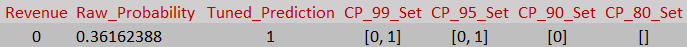

The number 0 under Revenue means this customer actually did not end up making a purchase. This is what happened in reality. Yet the Tuned_Prediction is 1, which means the standard model made a mistake and falsely predicted a sale. With a Raw_Probability of roughly 0.36 or 36%, the model saw enough positive signals to cross its decision threshold and label this person a buyer, but it was clearly far from certain.

This hidden doubt is exactly what the CP sets reveal and why they are so valuable. While the standard prediction blindly guaranteed a sale, the CP sets catch the hesitation. When 99% or 95% certainty is demanded, the model admits it cannot guarantee a purchase, outputting a [0, 1] set to show the person could easily go either way. Interestingly, when the requirement is lowered to 90%, the set shifts to [0], and at 80%, it yields an empty set. This mathematical instability perfectly illustrates a customer who is completely on the fence and highly unpredictable.

Knowing all these gives the marketing team a critical advantage. If it is only relied on the Tuned_Prediction, it would have assumed that this customer was a guaranteed buyer, offered them no incentives, and lost the sale (just as it happened in reality). Because this shopper is a true "persuadable", this is the exact scenario where deploying a strong 15% or 20% discount is the perfect approach to actively change their mind and push them toward a purchase.

All in all, the most profitable strategy here is to use CP to catch these uncertain customers before they leave. By offering a substantial discount to users where the CP set flags deep hesitation, we can convert lost opportunities into actual revenue without wasting budget on those who are already going to buy.

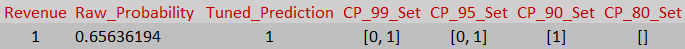

The number 1 under Revenue means this customer actually ended up making a purchase. This is what happened in real life. The Tuned_Prediction is also 1 which means that the model predicted the sale correctly. However, the Raw_Probability, which is roughly 0.65 or 65%, it is seen that the model was not completely confident.

This hesitation is exactly what the CP is used to solve. These sets show what the model does when it is forced to be mathematically certain. When 99% or 95% certainty is demanded, the model looks at its 65% confidence and realizes it cannot guarantee a purchase. It includes both 0 and 1 in the set to be safe (the person might or might not buy). But after the requirement is lowered to just 90% certainty, the model finally feels comfortable enough to drop the 0 and confidently labels them a buyer. The empty set at 80% happens because the math becomes unstable at lower strictness levels when a customer is so inpredictable. So the model refuses to make a decisive call there.

Knowing all these gives the marketing team a very clear outlook. Because this shopper is already leaning heavily towards buying, giving them a massive 20% or 30% discount would be a mistake. This specific customer instead just needs a tiny psychological nudge to get them over the finish line. A perfect approach, for instance, would be offering them free shipping if they complete their order within the next 15 minutes.

All in all, the most profitable strategy is to offer a small psychological incentive like free shipping that will simply speed up their decision, rather than offering a large discount and reducing the profit margin, given that this customer is already inclined to make a purchase.

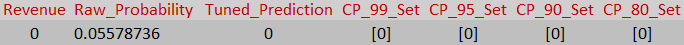

The number 0 under Revenue means this customer actually did not end up making a purchase. This is what happened in real life. The Tuned_Prediction is also 0 which means that the model predicted the lost sale correctly. With a Raw_Probability of roughly 0.05 or 5.5%, it is seen that the model was extremely confident that this person had no intention of buying.

This overwhelming confidence is exactly what the CP sets reflect. These sets show what the model does when it is forced to be mathematically certain. Even when the highest level of 99% certainty is demanded, the model looks at its tiny 5.5% probability and realizes it can absolutely guarantee this is a non-buyer. It confidently outputs just a 0 across every single strictness level, without ever needing to include a 1 just to be safe.

Knowing all these gives the marketing team a very clear outlook. Because this shopper has almost zero purchase intent, giving them a massive 20% or 30% discount would be a complete waste of marketing budget. This specific customer is highly unlikely to convert no matter what you offer them. A perfect approach, for instance, would be to simply save your promotional dollars here and perhaps just retarget them much later with a generic brand awareness campaign.

All in all, the most profitable strategy is to completely withhold your discounts and incentives from this user, as wasting margin on someone who is mathematically certain to bounce will only hurt your overall profitability.

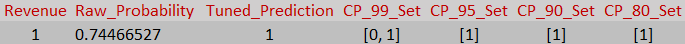

The number 1 under Revenue means this customer actually ended up making a purchase. This is the absolute reality of what happened. The Tuned_Prediction is also 1 which means that the model predicted the sale correctly. With a Raw_Probability of roughly 0.74 or 74%, it is seen that the model was quite confident though still leaving a small margin of doubt.

It includes both 0 and 1 in the set to be safe (the person might or might not buy). But because this customer's probability is relatively high, after the requirement is lowered to just 95% certainty, the model already feels comfortable enough to drop the 0 and confidently labels them a buyer. It remains completely stable and decisive at the 90% and 80% levels as well.

Knowing all these gives the marketing team a very clear outlook. Because this shopper is already highly likely to buy and giving them a massive 20% or 30% discount would be an unnecessary waste of money. This specific customer instead just needs a tiny psychological nudge to get them over the finish line.

All in all, the most profitable strategy is to offer a small psychological incentive like free shipping that will simply speed up their decision, rather than offering a large discount and reducing the profit margin, given that this customer is already strongly inclined to make a purchase.

***

Saving the analyzed dataset and the model used for analysis:

In [ ]:
predictions_spark_df.repartition(1).write.mode("overwrite") \
    .option("header", "true") \
    .csv("s3://probabilistic-purchase-prediction-asa-dataset-2026/dataset_analyzed.csv")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
s3_path = f"s3://probabilistic-purchase-prediction-asa-mlflow-artifacts-2026/models/m-084fd9890e624eb09c45bffe63c3edac/"
os.system(f"aws s3 cp {s3_path} ./model --recursive")
shutil.make_archive("best_model", 'zip', "./model")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

'/mnt/yarn/usercache/livy/appcache/application_1775200894659_0003/container_1775200894659_0003_01_000001/best_model.zip'

In [ ]:
os.system(f"aws s3 cp /mnt/yarn/usercache/livy/appcache/application_1775200894659_0003/container_1775200894659_0003_01_000001/best_model.zip s3://probabilistic-purchase-prediction-asa-mlflow-artifacts-2026/best_model.zip")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

0